# Energy-Layer Network Analysis — PolyCycle Park
Nodes: CHP, Olefins, Aromatics, EO/EG, PET  
Layer: Energy (steam/electricity flows between plants)

*Note: this notebook originally also included a Materials layer (MEG, feedstocks) built by a teammate as part of a joint multilayer analysis. That portion has been removed here — this version covers only the Energy layer, which is my individual contribution.*

In [1]:
# 1. Install packages (run once if needed)
# pip install pymnet networkx pandas matplotlib

In [2]:
import pymnet
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [3]:
# 2. Create network (Energy layer)
net = pymnet.MultiplexNetwork(couplings='categorical', fullyInterconnected=False)

# --- ENERGY LAYER (steam/electricity from CHP to plants, and return flows) ---
net['CHP', 'Olefins',   'Energy'] = 14615   # HP+MP+LP steam  [MJ/h]
net['CHP', 'Aromatics', 'Energy'] = 10280
net['CHP', 'EO/EG',     'Energy'] = 5688
net['CHP', 'PET',       'Energy'] = 5682
net['EO/EG', 'CHP',     'Energy'] = 19      # S-03 WHR steam return
net['PET',   'CHP',     'Energy'] = 1       # MP steam recovery

print('Nodes:', list(net.iter_nodes()))
print('Layers:', list(net.iter_layers()))


Nodes: ['Olefins', 'Aromatics', 'CHP', 'EO/EG', 'PET']
Layers: ['Materials', 'Energy']


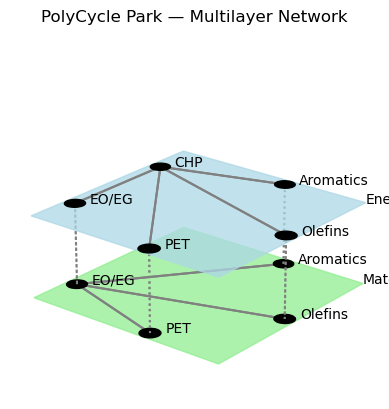

In [4]:
# 3. Visualize network
pymnet.draw(net, layout='circular',
            layerColorDict={'Energy': 'lightblue'})
plt.title('PolyCycle Park — Energy Layer Network')
plt.show()


In [5]:
# 4. Single-layer properties — Degree Centrality
layers = list(net.iter_layers())
edges  = list(net.edges)

for layer in layers:
    print('Layer:', layer)
    G = nx.DiGraph()
    for edge in edges:
        n1, n2, l1, l2 = edge[0], edge[1], edge[2], edge[3]
        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2)
    for node, degree in G.degree():
        print(node, 'C_D =', degree)
    print()

Layer: Materials
Olefins C_D = 1
EO/EG C_D = 3
Aromatics C_D = 1
PET C_D = 1

Layer: Energy
Olefins C_D = 1
CHP C_D = 4
Aromatics C_D = 1
EO/EG C_D = 1
PET C_D = 1



In [6]:
# Betweenness Centrality (intermediary companies)
for layer in layers:
    print('Layer:', layer)
    G = nx.DiGraph()
    for edge in edges:
        n1, n2, l1, l2 = edge[0], edge[1], edge[2], edge[3]
        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2)
    if len(G.nodes) > 0:
        bet = nx.betweenness_centrality(G, normalized=False)
        for node, value in bet.items():
            print(node, 'C_B =', round(value, 3))
    print()

Layer: Materials
Olefins C_B = 0.0
EO/EG C_B = 2.0
Aromatics C_B = 0.0
PET C_B = 0.0

Layer: Energy
Olefins C_B = 0.0
CHP C_B = 4.0
Aromatics C_B = 0.0
EO/EG C_B = 0.0
PET C_B = 0.0



In [7]:
# Graph Density
for layer in layers:
    print('Layer:', layer)
    G = nx.Graph()
    for edge in edges:
        n1, n2, l1, l2 = edge[0], edge[1], edge[2], edge[3]
        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2)
    N, M = len(G.nodes), len(G.edges)
    if N > 1:
        density = M / (N * (N - 1))
        print('Graph density =', round(density, 3))
    print()

Layer: Materials
Graph density = 0.25

Layer: Energy
Graph density = 0.2



In [8]:
# Strength (weighted degree)
for layer in layers:
    print('Layer:', layer)
    G = nx.DiGraph()
    for edge in edges:
        n1, n2, l1, l2, w = edge[0], edge[1], edge[2], edge[3], edge[4]
        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2, weight=w)
    for node in G.nodes():
        strength = sum(data['weight'] for _, _, data in G.edges(node, data=True))
        print(node, 'S =', strength)
    print()

Layer: Materials
Olefins S = 300
EO/EG S = 500
Aromatics S = 200
PET S = 0

Layer: Energy
Olefins S = 14615
CHP S = 20
Aromatics S = 10280
EO/EG S = 0
PET S = 0



In [9]:
# 5. Property Matrix (Nodes x Properties)
rows = []
for layer in layers:
    G = nx.DiGraph()
    for edge in edges:
        n1, n2, l1, l2, w = edge[0], edge[1], edge[2], edge[3], edge[4]
        if l1 == layer and l2 == layer:
            G.add_edge(n1, n2, weight=w)
    degree      = dict(G.degree())
    strength    = dict(G.degree(weight='weight'))
    betweenness = nx.betweenness_centrality(G, normalized=False)
    for node in G.nodes():
        rows.append({'Node': node, 'Layer': layer,
                     'Degree': degree[node],
                     'Strength': strength[node],
                     'Betweenness': betweenness[node]})

property_matrix = pd.DataFrame(rows)
print(property_matrix.to_string(index=False))

     Node     Layer  Degree  Strength  Betweenness
  Olefins Materials       1       300          0.0
    EO/EG Materials       3      1000          2.0
Aromatics Materials       1       200          0.0
      PET Materials       1       500          0.0
  Olefins    Energy       1     14615          0.0
      CHP    Energy       4     24915          4.0
Aromatics    Energy       1     10280          0.0
    EO/EG    Energy       1        19          0.0
      PET    Energy       1         1          0.0
